## Plot Function

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

def plot_network(
    points: tuple[float, float], 
    region: tuple[float, float, float, float], 
    radius: float
    )-> None:    
    _, ax = plt.subplots(figsize=(10, 8))
    
    ax.set_xlim(region[0], region[2])
    ax.set_ylim(region[1], region[3])
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_title(f'Networt with {len(points)} nodes (radius = {radius})')
    
    rect = plt.Rectangle((region[0], region[1]), 
                         region[2]-region[0], region[3]-region[1],
                         fill=False, linestyle='--', edgecolor='red', linewidth=1)
    ax.add_patch(rect)
    
    for i in range(len(points)):
        for j in range(i+1, len(points)):
            distance = np.sqrt((points[i][0]-points[j][0])**2 + (points[i][1]-points[j][1])**2)
            if distance <= radius:
                ax.plot([points[i][0], points[j][0]], [points[i][1], points[j][1]], 
                        color='#999999', linewidth=1, alpha=0.7)
    
    for (x, y) in points:
        circle = Circle((x, y), radius, 
                       fill=True, alpha=0.1,
                       edgecolor='lightblue', linewidth=1)
        ax.add_patch(circle)
    
    for i, (x, y) in enumerate(points):
        ax.plot(x, y, 'o', markersize=12, color='#4ECDC4', markeredgecolor='black')
        ax.text(x, y, str(i), color='black', ha='center', va='center')
    
    plt.show()

## Generator Random Network

In [10]:
import random
import math
import numpy as np
from collections import deque
from typing import Optional


Point2D = tuple[float, float]
RectangleRegion = tuple[float, float, float, float]

#=====================================
# PRIVATE HELPERS
#=====================================

def _is_connected(points: list[Point2D], radius: float) -> bool:
    """
    Checks whether the geometric graph induced by the point set is connected.

    Two points are adjacent if their Euclidean distance is <= radius.

    Parameters
    ----------
    points : list[(float, float)]
        Set of 2D coordinates.
    radius : float
        Communication radius.

    Returns
    -------
    bool
        True if the graph is connected, False otherwise.
    """
    if not points:
        return True

    visited: set[int] = set()
    queue: deque[int] = deque([0])

    adjacency: dict[int, list[int]] = {i: [] for i in range(len(points))}

    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            if math.dist(points[i], points[j]) <= radius:
                adjacency[i].append(j)
                adjacency[j].append(i)

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.add(node)
            queue.extend(adjacency[node])

    return len(visited) == len(points)


def _get_components(points: list[Point2D], radius: float) -> list[list[int]]:
    """
    Computes connected components of the geometric graph.
    """
    components: list[list[int]] = []
    visited: set[int] = set()

    for i in range(len(points)):
        if i in visited:
            continue

        component: list[int] = []
        queue: deque[int] = deque([i])

        while queue:
            node = queue.popleft()
            if node not in visited:
                visited.add(node)
                component.append(node)

                for j in range(len(points)):
                    if j != node and math.dist(points[node], points[j]) <= radius:
                        queue.append(j)

        components.append(component)

    return components


def _fallback_insert_point(
    points: list[Point2D],
    region: RectangleRegion,
    radius: float,
    rng: random.Random,
) -> Point2D:
    """
    Executes the fallback insertion strategy when no valid best_point
    is found during stochastic sampling.

    Strategy hierarchy:
    1) Try to connect disconnected components.
    2) Otherwise perform anchored random insertion.
    """
    x_min, y_min, x_max, y_max = region

    # -------------------------------------------------
    # Try to connect components
    # -------------------------------------------------
    if len(points) > 1:
        components = _get_components(points, radius)

        if len(components) > 1:
            comp1, comp2 = rng.sample(components, 2)
            p1 = points[rng.choice(comp1)]
            p2 = points[rng.choice(comp2)]

            mid_x = (p1[0] + p2[0]) / 2
            mid_y = (p1[1] + p2[1]) / 2

            direction = math.atan2(p2[1] - p1[1], p2[0] - p1[0])

            new_x = mid_x + rng.uniform(-0.3 * radius, 0.3 * radius) * math.sin(direction)
            new_y = mid_y + rng.uniform(-0.3 * radius, 0.3 * radius) * math.cos(direction)

            new_x = float(np.clip(new_x, x_min, x_max))
            new_y = float(np.clip(new_y, y_min, y_max))

            return (new_x, new_y)

    # -------------------------------------------------
    # Anchored random insertion
    # -------------------------------------------------
    anchor = rng.choice(points)

    angle = rng.uniform(0, 2 * math.pi)
    distance = rng.uniform(0, radius)

    new_x = anchor[0] + distance * math.cos(angle)
    new_y = anchor[1] + distance * math.sin(angle)

    new_x = float(np.clip(new_x, x_min, x_max))
    new_y = float(np.clip(new_y, y_min, y_max))

    return (new_x, new_y)


def _repair_connectivity(
    points: list[Point2D],
    radius: float,
    rng: random.Random,
) -> list[Point2D]:
    """
    Ensures global connectivity by iteratively inserting midpoint relays
    between disconnected components.
    """
    components = _get_components(points, radius)

    while len(components) > 1:
        comp1, comp2 = rng.sample(components, 2)

        p1 = points[rng.choice(comp1)]
        p2 = points[rng.choice(comp2)]

        mid_x = (p1[0] + p2[0]) / 2
        mid_y = (p1[1] + p2[1]) / 2

        points.append((mid_x, mid_y))

        components = _get_components(points, radius)

    return points


#=====================================
# PUBLIC API
#=====================================

def continuous_network_gen(
    amount: int,
    region: RectangleRegion,
    radius: float,
    sink: Point2D,
    rng: random.Random,
    max_attempts: int = 100
) -> list[Point2D]:
    """
    Generates spatial points attempting to maximize coverage while
    preserving geometric connectivity.

    Growth model:
    - Seed at region center.
    - Iteratively sample anchored candidates.
    - Select the point maximizing minimum distance.
    - Apply fallback insertion when sampling fails.
    - Perform final connectivity repair if necessary.

    Parameters
    ----------
    amount : int
        Number of points to generate.
    region : (x_min, y_min, x_max, y_max)
        Rectangular spatial domain.
    radius : float
        Communication radius.
    sink: (float, float)
        Sink position (if None, uses region center).
    rng : random.Random
        RNG for reproducibility.
    max_attempts : int
        Candidate samples per iteration.

    Returns
    -------
    list[(float, float)]
        Generated point set.
    """
    if amount <= 0:
        return []

    x_min, y_min, x_max, y_max = region

    points: list[Point2D] = []

    # -------------------------------------------------
    # Sink position or seed at geometric center as sink
    # -------------------------------------------------
    first_x = sink[0] if sink else (x_min + x_max) / 2
    first_y = sink[1] if sink else (y_min + y_max) / 2
    points.append((first_x, first_y))

    # -------------------------------------------------
    # Growth process
    # -------------------------------------------------
    while len(points) < amount + 1: # +1 for sink

        best_point: Optional[Point2D] = None
        max_min_distance = 0.0

        for _ in range(max_attempts):

            anchor = rng.choice(points)

            angle = rng.uniform(0, 2 * math.pi)
            distance = rng.uniform(0.5 * radius, radius)

            new_x = anchor[0] + distance * math.cos(angle)
            new_y = anchor[1] + distance * math.sin(angle)

            if not (x_min <= new_x <= x_max and y_min <= new_y <= y_max):
                continue

            candidate = (new_x, new_y)
            temp_points = points + [candidate]

            if _is_connected(temp_points, radius):

                min_dist = min(math.dist(candidate, p) for p in points)

                if min_dist > max_min_distance:
                    max_min_distance = min_dist
                    best_point = candidate

        # -------------------------------------------------
        # Insert best candidate or fallback
        # -------------------------------------------------
        if best_point is not None:
            points.append(best_point)
        else:
            new_point = _fallback_insert_point(points, region, radius, rng)
            points.append(new_point)

    # -------------------------------------------------
    # Final repair
    # -------------------------------------------------
    if not _is_connected(points, radius):
        points = _repair_connectivity(points, radius, rng)

    return points[1:] # exclude sink

 ## Make Graph Connected

In [12]:
import math

Point2D = tuple[float, float]

#-------------------------------------------------
# Modification Methods
#-------------------------------------------------

def _dist(p: Point2D, q: Point2D) -> float:
    return math.hypot(p[0] - q[0], p[1] - q[1])


def _connected_components(points: list[Point2D], radius: float) -> list[list[int]]:
    """
    Retorna as componentes conexas como listas de índices.
    """
    n = len(points)
    visited = [False] * n
    adj = [[] for _ in range(n)]

    for i in range(n):
        for j in range(i + 1, n):
            if _dist(points[i], points[j]) <= radius:
                adj[i].append(j)
                adj[j].append(i)

    components = []

    for i in range(n):
        if not visited[i]:
            stack = [i]
            visited[i] = True
            comp = []

            while stack:
                u = stack.pop()
                comp.append(u)
                for v in adj[u]:
                    if not visited[v]:
                        visited[v] = True
                        stack.append(v)

            components.append(comp)

    return components


def _translate_component(
    points: list[Point2D],
    component: list[int],
    direction: tuple[float, float],
    delta: float
) -> None:
    """
    Move uma componente inteira ao longo de um vetor unitário 'direction'.
    """
    dx = direction[0] * delta
    dy = direction[1] * delta

    for i in component:
        x, y = points[i]
        points[i] = (x + dx, y + dy)


def make_graph_connected(
    points: list[Point2D],
    radius: float,
    step: float = 0.1
) -> list[Point2D]:
    """
    Modifica as posições dos pontos até que o grafo fique conexo,
    preservando a geometria interna das componentes.
    """
    points = points.copy()
    root = points[0]

    while True:
        components = _connected_components(points, radius)

        # Se já é conexo
        if len(components) == 1:
            break

        # Identifica componente da raiz
        root_comp = None
        for comp in components:
            if 0 in comp:
                root_comp = comp
                break

        assert root_comp is not None

        # Processa uma componente externa por vez
        for comp in components:
            if comp is root_comp:
                continue

            # Escolhe um ponto qualquer da componente
            idx = comp[0]
            px, py = points[idx]

            # Direção radial para a raiz
            vx = root[0] - px
            vy = root[1] - py
            norm = math.hypot(vx, vy)
            direction = (vx / norm, vy / norm)

            # Move incrementalmente até conectar
            while True:
                _translate_component(points, comp, direction, step)

                # Testa se houve conexão
                for i in comp:
                    for j in root_comp:
                        if _dist(points[i], points[j]) <= radius:
                            break
                    else:
                        continue
                    break
                else:
                    continue

                break

            break  # reavaliar componentes após cada conexão

    return points

## Testing

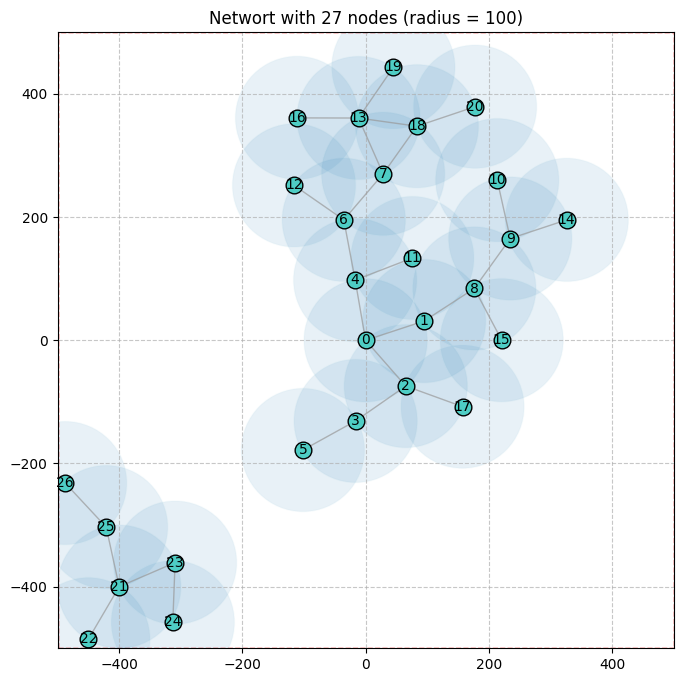

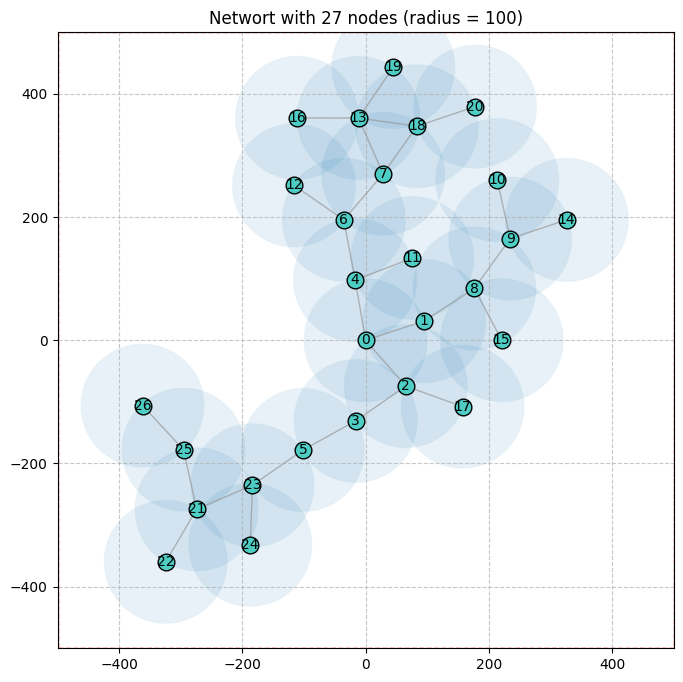

In [16]:
REGION = (-500, -500, 500, 500)
RADIUS = 100        
N1 = 20             
N2 = 5
S1 = (0, 0)
S2 = (-400, -400)
RNG = random.Random(42) 

p1 = continuous_network_gen(N1, REGION, RADIUS, S1, RNG)
p2 = continuous_network_gen(N2, REGION, RADIUS, S2, RNG)

P = [S1] + p1 + [S2] + p2 

plot_network(P, REGION, RADIUS)

Q = make_graph_connected(P, RADIUS)

plot_network(Q, REGION, RADIUS)